In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

In [2]:
# ── Estilo global — idéntico al resto del informe ────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'savefig.dpi'      : 200,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'legend.fontsize'  : 9,
    'legend.framealpha': 0.92,
    'legend.edgecolor' : '#DDDDDD',
    'axes.titleweight' : 'bold',
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
})

# ── Paleta — valores exactos del resto del informe ───────────────────────────
C_BLUE  = '#4C72B0'   # seaborn tab10-0  (Regresión Logística / demográficas)
C_ORG   = '#DD8452'   # seaborn tab10-1  (XGBoost / otros)
C_GRN   = '#55A868'   # seaborn tab10-2  (Random Forest)
C_RED   = '#C44E52'   # seaborn tab10-3  (BASC-3 / cognitivo)
C_PURP  = '#8172B2'   # seaborn tab10-4
C_GRAY  = '#8C8C8C'   # gris neutro      (CV bars)
C_TITLE = '#1A3F6F'   # azul oscuro para títulos
C_MUTED = '#555555'   # gris texto secundario

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# PARÁMETROS GLOBALES — modificar según necesidad
# ════════════════════════════════════════════════════════════════════════════
DATA_PATH = '../data/processed/processed_data.csv'   # ruta al CSV procesado
RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_SPLITS_CV  = 5
N_ESTIMATORS = 300   # árboles en Random Forest

FEATURES = [
    'edad', 'sexo', 'escolaridad', 'lateralidad',
    'antecedentes_familiares', 'antecedentes_obstetricos', 'retrasos_desarrollo',
    'cit', 'agresividad_basc3', 'hiperactividad_basc3',
    'problemas_conducta_basc3', 'problemas_atencion_basc3',
    'atipicidad_basc3', 'fluidez_fonologica',
]
FEATURES_CAT = [
    'sexo', 'lateralidad',
    'antecedentes_familiares', 'antecedentes_obstetricos', 'retrasos_desarrollo',
]
FEATURE_LABELS = {
    'problemas_atencion_basc3' : 'Problemas de atención (BASC-3)',
    'hiperactividad_basc3'     : 'Hiperactividad (BASC-3)',
    'problemas_conducta_basc3' : 'Problemas de conducta (BASC-3)',
    'agresividad_basc3'        : 'Agresividad (BASC-3)',
    'atipicidad_basc3'         : 'Atipicidad (BASC-3)',
    'cit'                      : 'Coef. Intelectual (CIT)',
    'fluidez_fonologica'       : 'Fluidez fonológica',
    'antecedentes_familiares'  : 'Antecedentes familiares',
    'retrasos_desarrollo'      : 'Retrasos del desarrollo',
    'antecedentes_obstetricos' : 'Antecedentes obstétricos',
    'edad'                     : 'Edad',
    'escolaridad'              : 'Escolaridad',
    'sexo'                     : 'Sexo',
    'lateralidad'              : 'Lateralidad',
}
# Features que pertenecen al bloque BASC-3 / cognitivo (color C_RED en Fig 9)
BASC_FEATS = [
    'agresividad_basc3', 'hiperactividad_basc3',
    'problemas_conducta_basc3', 'problemas_atencion_basc3',
    'atipicidad_basc3', 'cit', 'fluidez_fonologica',
]

# ── Cargar datos ──────────────────────────────────────────────────────────────
df  = pd.read_csv(DATA_PATH)
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X   = df[FEATURES].copy()
X[FEATURES_CAT] = enc.fit_transform(X[FEATURES_CAT])
y   = df['etiqueta']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_STATE)

rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

print(f"Datos: {df.shape[0]} filas · {df.shape[1]} columnas")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Clases: {y.nunique()}")


Datos: 875 filas · 18 columnas
Train: 700 | Test: 175
Clases: 13


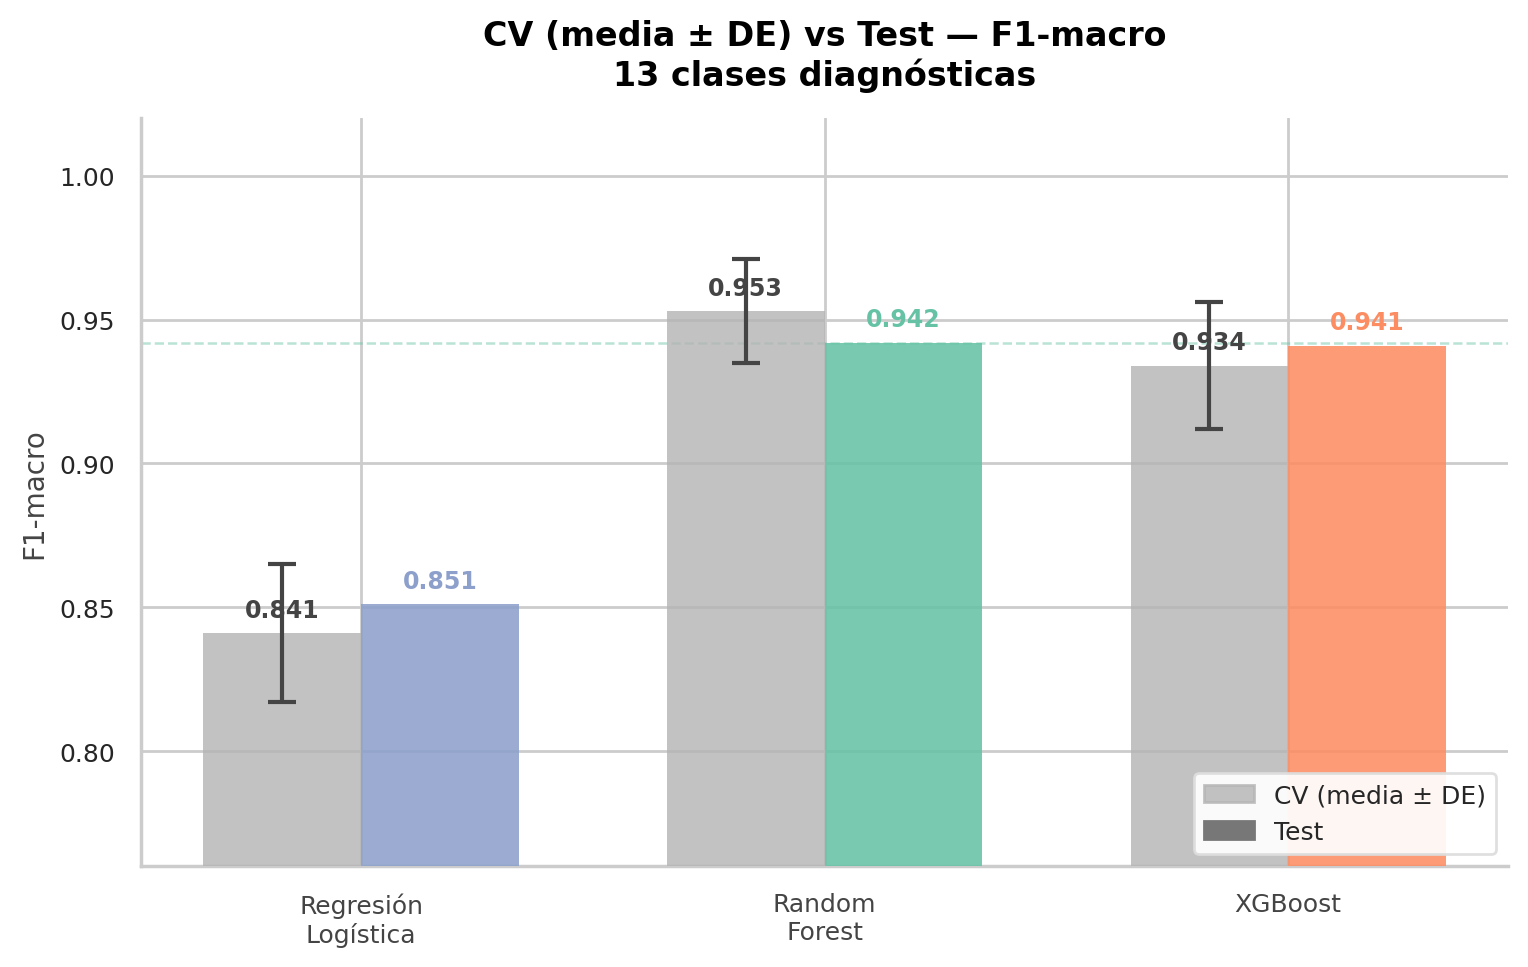

In [23]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURA 6 — Comparación de modelos: CV (media ± DE) vs Test F1-macro
# ════════════════════════════════════════════════════════════════════════════

# ── Parámetros ────────────────────────────────────────────────────────────────
FIG6_FIGSIZE   = (8, 5.2)
FIG6_DPI       = 200
FIG6_SAVE_PATH = None   # None = solo mostrar

# Datos — editar con los valores de cada experimento
MODELOS = ['Regresión\nLogística', 'Random\nForest', 'XGBoost']
CV_VALS  = [0.841, 0.953, 0.934]   # F1-macro media CV
CV_DES   = [0.024, 0.018, 0.022]   # desviación estándar CV
TEST_VALS= [0.851, 0.942, 0.941]   # F1-macro en test
# Color de barra Test por modelo (debe coincidir con paleta del informe)
TEST_COLS= [C_BLUE, C_GRN, C_ORG]
# Índice del mejor modelo para línea de referencia (0-based)
BEST_IDX = 1   # Random Forest

# ── Gráfica ───────────────────────────────────────────────────────────────────
x, w = np.arange(len(MODELOS)), 0.34
fig, ax = plt.subplots(figsize=FIG6_FIGSIZE, dpi=FIG6_DPI)
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

bars_cv   = ax.bar(x - w/2, CV_VALS,   w, color=C_GRAY, alpha=0.80, label='CV (media ± DE)', zorder=3, linewidth=0)
bars_test = ax.bar(x + w/2, TEST_VALS, w, color=TEST_COLS, alpha=0.88, label='Test', zorder=3, linewidth=0)

ax.errorbar(x - w/2, CV_VALS, yerr=CV_DES, fmt='none',
            ecolor='#444444', elinewidth=1.5, capsize=5, capthick=1.5, zorder=5)

for bar, val in zip(bars_cv, CV_VALS):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.004, f'{val:.3f}',
            ha='center', va='bottom', fontsize=8.5, color='#444444', fontweight='bold')
for bar, val, c in zip(bars_test, TEST_VALS, TEST_COLS):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.004, f'{val:.3f}',
            ha='center', va='bottom', fontsize=8.5, color=c, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(MODELOS, fontsize=10, color=C_MUTED)
ax.set_ylabel('F1-macro', fontsize=10, color=C_MUTED)
ax.set_ylim(0.76, 1.02); ax.tick_params(labelsize=9)
ax.set_title('CV (media ± DE) vs Test — F1-macro\n13 clases diagnósticas',
             fontsize=12, fontweight='bold', color='black', pad=12)

legend_cv   = mpatches.Patch(color=C_GRAY, alpha=0.80, label='CV (media ± DE)')
legend_test = mpatches.Patch(color='#777777', label='Test')
ax.legend(handles=[legend_cv, legend_test], loc='lower right', fontsize=9)
ax.axhline(TEST_VALS[BEST_IDX], color=TEST_COLS[BEST_IDX], linestyle='--',
           linewidth=0.9, alpha=0.45, zorder=2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(pad=1.6)
if FIG6_SAVE_PATH:
    plt.savefig(FIG6_SAVE_PATH, dpi=FIG6_DPI, bbox_inches='tight', facecolor='white')
    print(f"Guardado: {FIG6_SAVE_PATH}")
plt.show()


Importancia acumulada BASC-3 + cognitivo : 0.900  (90.0%)
Importancia demográficas + antecedentes  : 0.100  (10.0%)
Feature más importante: 'Problemas de atención (BASC-3)'


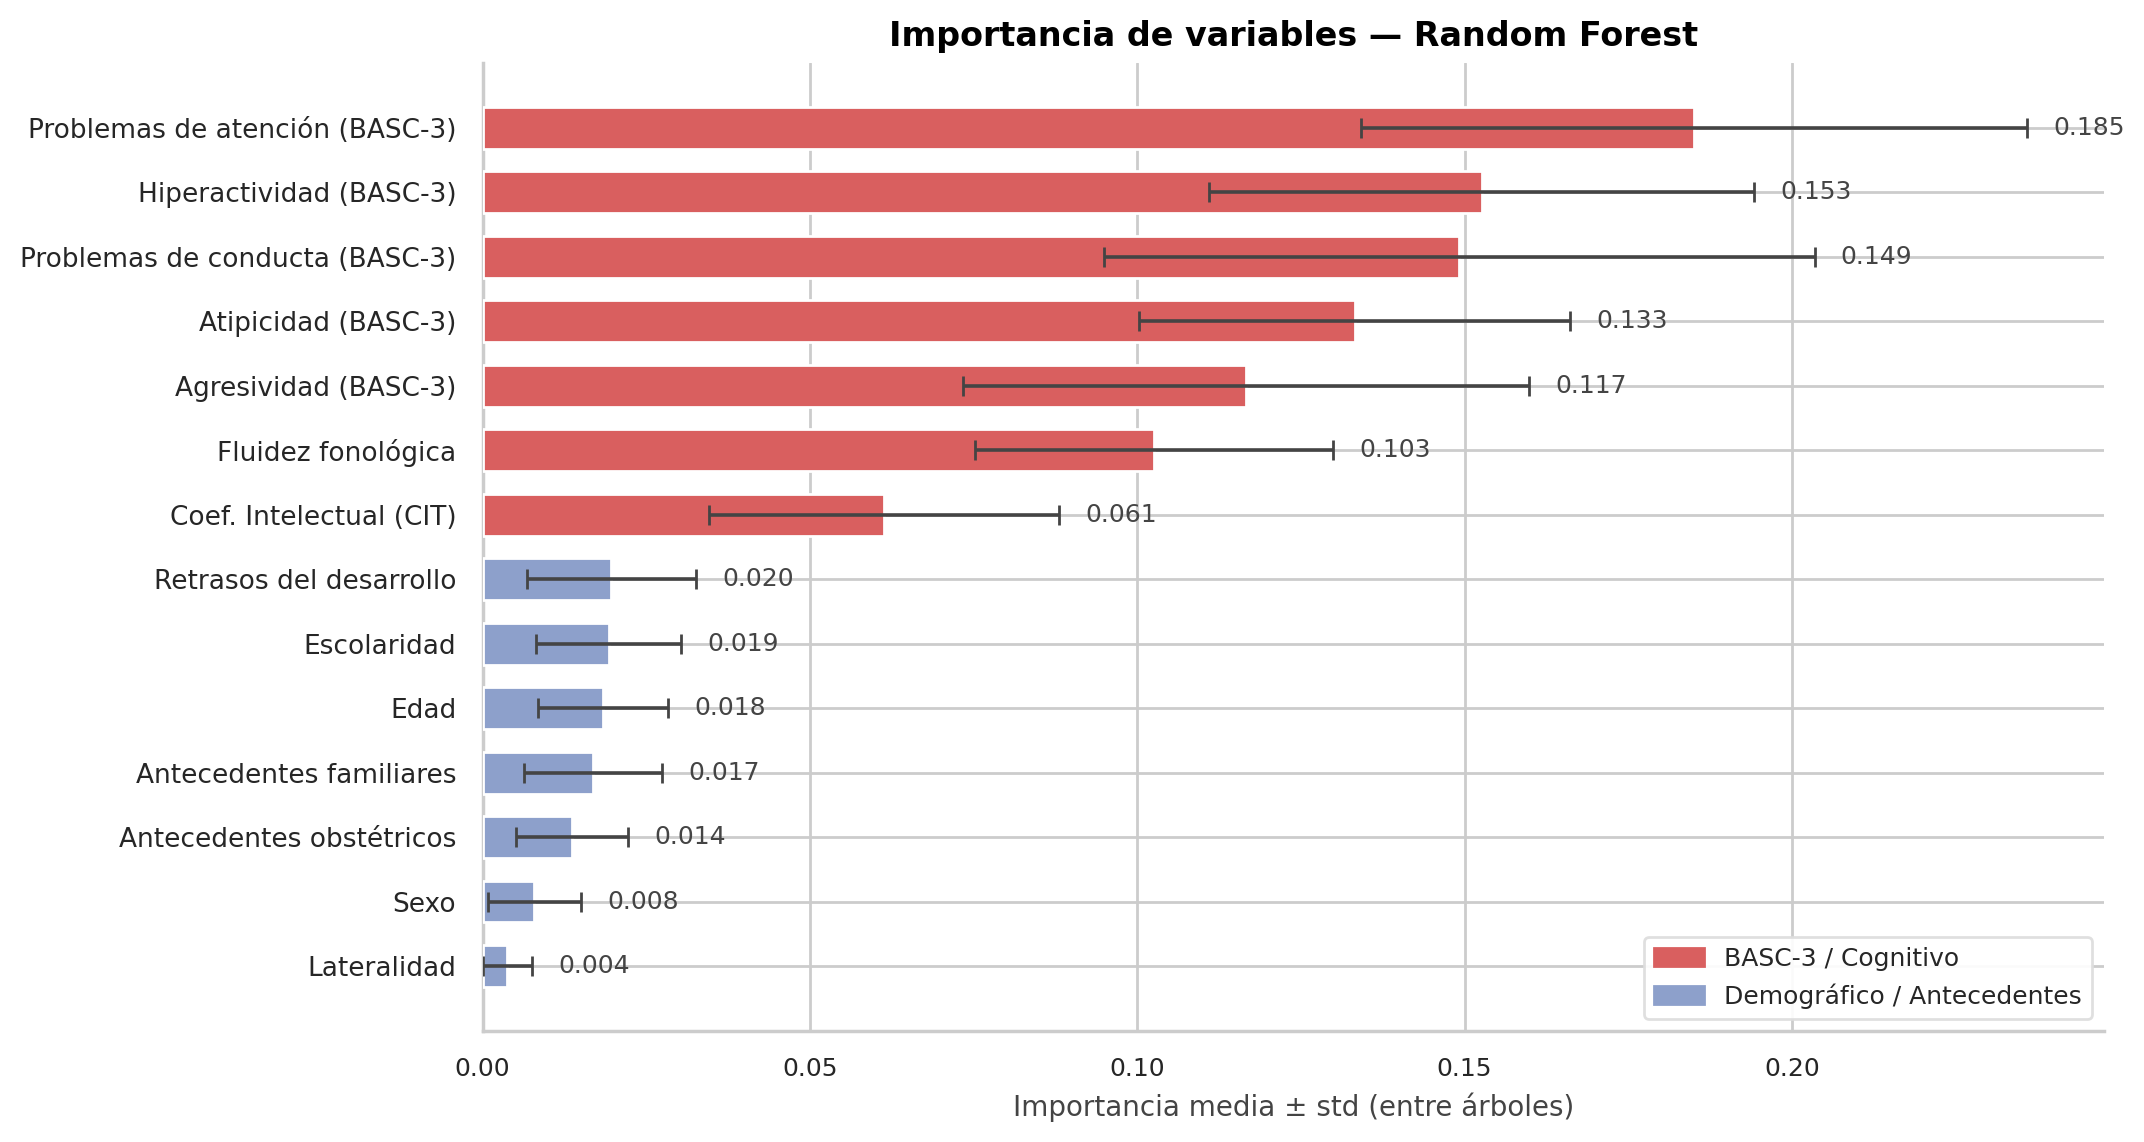

In [14]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURA 9 — Importancia de variables del modelo Random Forest
# ════════════════════════════════════════════════════════════════════════════

# ── Parámetros ────────────────────────────────────────────────────────────────
FIG9_FIGSIZE    = (11, 6)
FIG9_DPI        = 200
FIG9_SAVE_PATH  = None    # None = solo mostrar
FIG9_TOP_N      = None    # None = mostrar todas; int = top N features
# Colores de barras por grupo de feature
COL_BASC_COG    = C_RED   # BASC-3 + CIT + fluidez fonológica
COL_DEMO        = C_BLUE  # demográficas, antecedentes, escolaridad
COL_BASC_LABEL  = 'BASC-3 / Cognitivo'
COL_DEMO_LABEL  = 'Demográfico / Antecedentes'

# ── Calcular importancia media ± std entre árboles ────────────────────────────
imp_mean = rf.feature_importances_
imp_std  = np.std([t.feature_importances_ for t in rf.estimators_], axis=0)
imp_df   = pd.DataFrame({'mean': imp_mean, 'std': imp_std}, index=FEATURES)
imp_df   = imp_df.sort_values('mean', ascending=True)

if FIG9_TOP_N:
    imp_df = imp_df.sort_values('mean', ascending=False).head(FIG9_TOP_N).sort_values('mean')

labels   = [FEATURE_LABELS.get(f, f) for f in imp_df.index]
bar_cols = [COL_BASC_COG if f in BASC_FEATS else COL_DEMO for f in imp_df.index]

# ── Gráfica ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIG9_FIGSIZE, dpi=FIG9_DPI)
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

ax.barh(labels, imp_df['mean'], xerr=imp_df['std'],
        color=bar_cols, edgecolor='white', height=0.65,
        error_kw=dict(ecolor='#444444', capsize=3.5, elinewidth=1.3), zorder=3)

for i, (mean, std) in enumerate(zip(imp_df['mean'], imp_df['std'])):
    ax.text(mean + std + 0.004, i, f'{mean:.3f}',
            va='center', fontsize=9, color=C_MUTED)

p_basc = mpatches.Patch(color=COL_BASC_COG,  label=COL_BASC_LABEL)
p_demo = mpatches.Patch(color=COL_DEMO,      label=COL_DEMO_LABEL)
ax.legend(handles=[p_basc, p_demo], fontsize=9, framealpha=0.92)
ax.set_xlabel('Importancia media ± std (entre árboles)', fontsize=10, color=C_MUTED)
ax.set_title('Importancia de variables — Random Forest',
             fontsize=12, fontweight='bold', color='black')
ax.tick_params(axis='y', labelsize=9.5); ax.tick_params(axis='x', labelsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Resumen cuantitativo
basc_tot = imp_df.loc[[f for f in imp_df.index if f in BASC_FEATS], 'mean'].sum()
print(f"Importancia acumulada BASC-3 + cognitivo : {basc_tot:.3f}  ({basc_tot*100:.1f}%)")
print(f"Importancia demográficas + antecedentes  : {1-basc_tot:.3f}  ({(1-basc_tot)*100:.1f}%)")
print(f"Feature más importante: '{FEATURE_LABELS.get(imp_df['mean'].idxmax(), imp_df['mean'].idxmax())}'")

plt.tight_layout(pad=1.4)
if FIG9_SAVE_PATH:
    plt.savefig(FIG9_SAVE_PATH, dpi=FIG9_DPI, bbox_inches='tight', facecolor='white')
    print(f"Guardado: {FIG9_SAVE_PATH}")
plt.show()


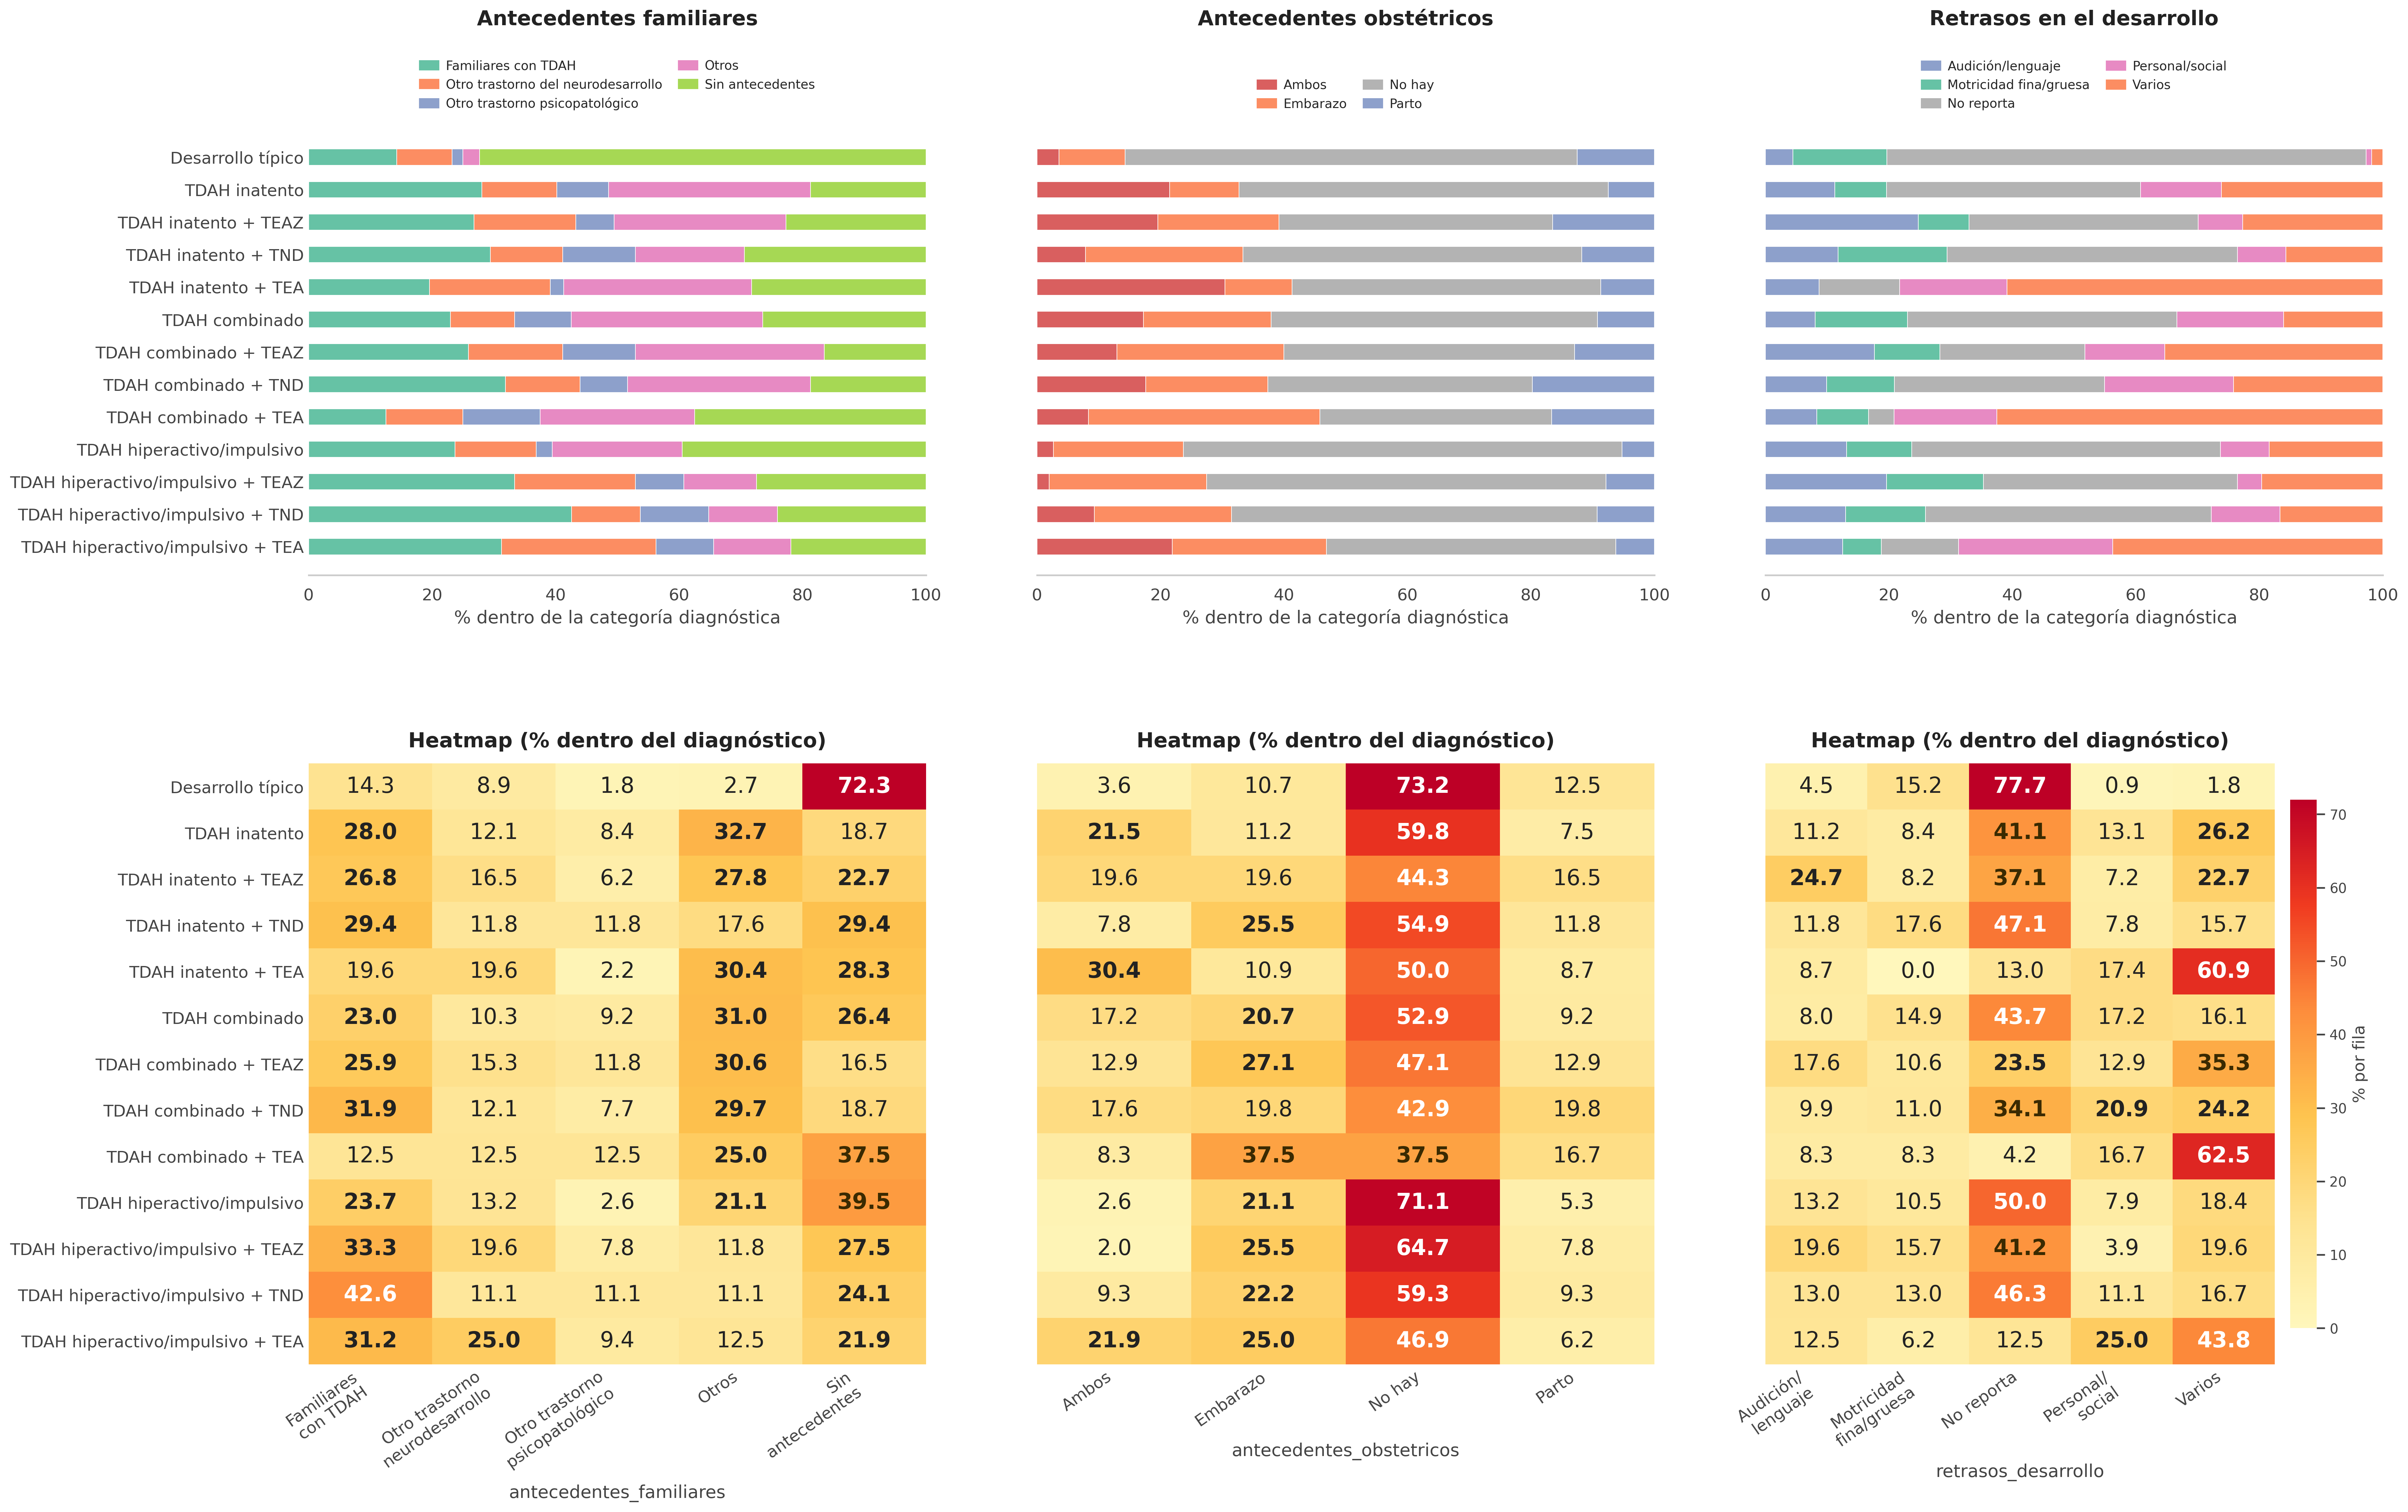

In [22]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURA 5 — Antecedentes clínicos × Etiqueta diagnóstica
# Sin grids + etiquetas ampliadas + heatmap legible
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

# ── Parámetros ─────────────────────────────────────────────────────────────
FIG5_FIGSIZE   = (24, 17)
FIG5_DPI       = 300
FIG5_SAVE_PATH = None  # Ejemplo: "figura5_antecedentes.png"

C_TITLE = "#222222"
C_MUTED = "#444444"

# ── Colores para barras apiladas ──────────────────────────────────────────
C_1 = "#66C2A5"
C_2 = "#FC8D62"
C_3 = "#8DA0CB"
C_4 = "#E78AC3"
C_5 = "#A6D854"
C_6 = "#B3B3B3"
C_7 = "#D95F5F"

# ── Orden de etiquetas ────────────────────────────────────────────────────
ORDEN = [
    'TDAH hiperactivo/impulsivo + TEA',
    'TDAH hiperactivo/impulsivo + TND',
    'TDAH hiperactivo/impulsivo + TEAZ',
    'TDAH hiperactivo/impulsivo',
    'TDAH combinado + TEA',
    'TDAH combinado + TND',
    'TDAH combinado + TEAZ',
    'TDAH combinado',
    'TDAH inatento + TEA',
    'TDAH inatento + TND',
    'TDAH inatento + TEAZ',
    'TDAH inatento',
    'Desarrollo típico',
]

ORDEN_HEAT = list(reversed(ORDEN))

# ── Variables ─────────────────────────────────────────────────────────────
ANTEC_COLS = [
    ('antecedentes_familiares',  'Antecedentes familiares'),
    ('antecedentes_obstetricos', 'Antecedentes obstétricos'),
    ('retrasos_desarrollo',      'Retrasos en el desarrollo'),
]

# ── Paletas ───────────────────────────────────────────────────────────────
PALETAS = {
    'antecedentes_familiares': {
        'Familiares con TDAH':                C_1,
        'Otro trastorno del neurodesarrollo': C_2,
        'Otro trastorno psicopatológico':     C_3,
        'Otros':                              C_4,
        'Sin antecedentes':                   C_5,
    },
    'antecedentes_obstetricos': {
        'Ambos':    C_7,
        'Embarazo': C_2,
        'No hay':   C_6,
        'Parto':    C_3,
    },
    'retrasos_desarrollo': {
        'Audición/lenguaje':      C_3,
        'Motricidad fina/gruesa': C_1,
        'No reporta':             C_6,
        'Personal/social':        C_4,
        'Varios':                 C_2,
    },
}

# ── Etiquetas X abreviadas ────────────────────────────────────────────────
XLABELS_MAP = {
    'Familiares con TDAH':                'Familiares\ncon TDAH',
    'Otro trastorno del neurodesarrollo': 'Otro trastorno\nneurodesarrollo',
    'Otro trastorno psicopatológico':     'Otro trastorno\npsicopatológico',
    'Otros':                              'Otros',
    'Sin antecedentes':                   'Sin\nantecedentes',

    'Ambos':                              'Ambos',
    'Embarazo':                           'Embarazo',
    'No hay':                             'No hay',
    'Parto':                              'Parto',

    'Audición/lenguaje':                  'Audición/\nlenguaje',
    'Motricidad fina/gruesa':             'Motricidad\nfina/gruesa',
    'No reporta':                         'No reporta',
    'Personal/social':                    'Personal/\nsocial',
    'Varios':                             'Varios',
}

# ── Estilo global ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ── Heatmap amarillo → rojo ───────────────────────────────────────────────
hmap_cmap = LinearSegmentedColormap.from_list(
    "heat_yellow_red",
    ["#FFF7BC", "#FEE391", "#FEC44F", "#FD8D3C", "#F03B20", "#BD0026"],
    N=256
)

# ── Figura ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=FIG5_FIGSIZE, dpi=FIG5_DPI)
fig.patch.set_facecolor("white")

gs = GridSpec(
    2, 3,
    figure=fig,
    height_ratios=[0.78, 1.05],
    hspace=0.36,
    wspace=0.18,
    top=0.84,
    bottom=0.10,
    left=0.085,
    right=0.965
)

for col_i, (var, titulo) in enumerate(ANTEC_COLS):

    tab = pd.crosstab(df["etiqueta"], df[var], normalize="index") * 100

    cats = [c for c in PALETAS[var].keys() if c in tab.columns]

    tab_bar = tab.reindex(ORDEN).dropna(how="all")[cats]
    tab_heat = tab.reindex(ORDEN_HEAT).dropna(how="all")[cats]

    # ═══════════════════════════════════════════════════════════════════════
    # 1. Barras apiladas
    # ═══════════════════════════════════════════════════════════════════════
    ax = fig.add_subplot(gs[0, col_i])

    left = np.zeros(len(tab_bar))

    for cat in tab_bar.columns:
        ax.barh(
            np.arange(len(tab_bar)),
            tab_bar[cat].values,
            left=left,
            color=PALETAS[var][cat],
            edgecolor="white",
            linewidth=0.45,
            height=0.50
        )
        left += tab_bar[cat].values

    ax.set_title(
        titulo,
        fontsize=15,
        fontweight="bold",
        color=C_TITLE,
        pad=76
    )

    ax.set_xlim(0, 100)

    ax.set_xlabel(
        "% dentro de la categoría diagnóstica",
        color=C_MUTED,
        fontsize=13
    )

    ax.set_yticks(np.arange(len(tab_bar)))

    if col_i == 0:
        ax.set_yticklabels(
            tab_bar.index,
            color=C_MUTED,
            fontsize=12
        )
    else:
        ax.set_yticklabels([])

    # Sin grids
    ax.grid(False)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.spines["bottom"].set_color("#CCCCCC")

    ax.tick_params(axis="y", length=0)
    ax.tick_params(
        axis="x",
        colors=C_MUTED,
        labelsize=12
    )

    handles = [
        mpatches.Patch(color=PALETAS[var][cat], label=cat)
        for cat in tab_bar.columns
    ]

    ax.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=2 if len(handles) > 3 else len(handles),
        fontsize=9.3,
        frameon=False,
        handlelength=1.5,
        columnspacing=1.3,
        handletextpad=0.55,
        borderaxespad=0.0
    )

    # ═══════════════════════════════════════════════════════════════════════
    # 2. Heatmap
    # ═══════════════════════════════════════════════════════════════════════
    axh = fig.add_subplot(gs[1, col_i])

    heat_data = tab_heat.values

    im = axh.imshow(
        heat_data,
        aspect="auto",
        cmap=hmap_cmap,
        vmin=0,
        vmax=72,
        interpolation="nearest"
    )

    for r in range(heat_data.shape[0]):
        for c in range(heat_data.shape[1]):

            val = heat_data[r, c]

            if val >= 42:
                text_color = "white"
            elif val >= 34:
                text_color = "#3A2A00"
            else:
                text_color = "#222222"

            axh.text(
                c,
                r,
                f"{val:.1f}",
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold" if val >= 20 else "normal",
                color=text_color
            )

    axh.set_title(
        "Heatmap (% dentro del diagnóstico)",
        fontsize=15,
        fontweight="bold",
        color=C_TITLE,
        pad=12
    )

    axh.set_xticks(np.arange(len(tab_heat.columns)))

    axh.set_xticklabels(
        [XLABELS_MAP.get(c, c) for c in tab_heat.columns],
        rotation=35,
        ha="right",
        color=C_MUTED,
        fontsize=12
    )

    axh.set_yticks(np.arange(len(tab_heat)))

    if col_i == 0:
        axh.set_yticklabels(
            tab_heat.index,
            color=C_MUTED,
            fontsize=12
        )
    else:
        axh.set_yticklabels([])

    axh.set_xlabel(
        var,
        color=C_MUTED,
        fontsize=13,
        labelpad=10
    )

    axh.tick_params(axis="both", length=0)

    # Sin grids ni líneas internas
    axh.grid(False)

    for spine in axh.spines.values():
        spine.set_visible(False)

    if col_i == 2:
        cbar = fig.colorbar(
            im,
            ax=axh,
            shrink=0.88,
            pad=0.025
        )

        cbar.set_label(
            "% por fila",
            fontsize=12,
            color=C_MUTED
        )

        cbar.ax.tick_params(
            labelsize=10,
            colors=C_MUTED
        )

        cbar.outline.set_visible(False)

if FIG5_SAVE_PATH:
    plt.savefig(
        FIG5_SAVE_PATH,
        dpi=FIG5_DPI,
        bbox_inches="tight",
        facecolor="white"
    )

plt.show()